# Xenium Prime 5K Breast — V1006 representation-first CCC niches

Only directed CCC enters training. Cell type is used only for interpretation.

In [1]:
from pathlib import Path
import sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path('/home/xueshuailin/CCC_Phe/V1006')
SOURCE = ROOT / 'src'
if str(SOURCE) not in sys.path: sys.path.insert(0, str(SOURCE))
from phenoniche.v1006.pipeline import ensure_results
from phenoniche.v1006.data import load_prepared_input
from phenoniche.v1006.reporting import (training_curves, spatial_overview, niche_celltype_enrichment,
    spatial_each_niche, niche_size_plot, representative_h_heatmap)
artifacts = ensure_results()
summary, output = artifacts['summary'], artifacts['output']


## 1. Prime 5K data summary

In [2]:
pd.Series({'cells': summary['n_cells'], 'original CCC features': summary['n_input_features'],
           'retained CCC features': summary['n_retained_features'], 'latent dimension': 32,
           'final niches': 8}, name='V1006')

cells                    699110
original CCC features       494
retained CCC features       450
latent dimension             32
final niches                  8
Name: V1006, dtype: int64

## 2. Model summary

In [3]:
print('CCC F → nonlinear encoder → embedding E32 → nonlinear AE decoder')
print('E32 → activity a and simplex mixture P32; Z32 = a × P32')
print('Interpretable decoder: Z32 H32 ≈ CCC; 8 hierarchical niches × 4 learned subprograms')

CCC F → nonlinear encoder → embedding E32 → nonlinear AE decoder
E32 → activity a and simplex mixture P32; Z32 = a × P32
Interpretable decoder: Z32 H32 ≈ CCC; 8 hierarchical niches × 4 learned subprograms


## 3. Training loss

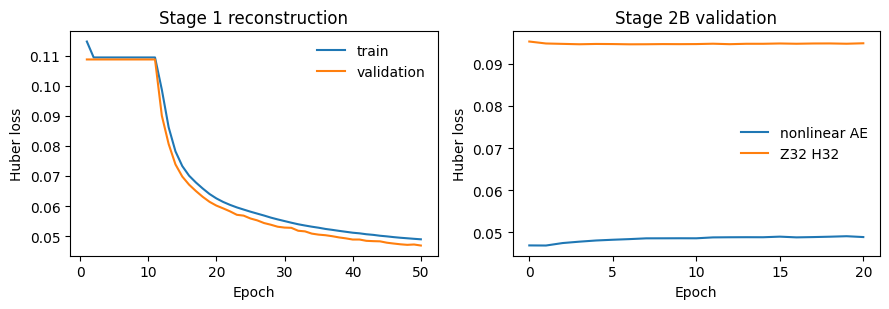

Stage 1 best epoch                   50.000000
Stage 1 validation reconstruction     0.046899
Stage 2A best epoch                  15.000000
Stage 2B selected epoch              20.000000
Stage 2 validation AE                 0.048881
Stage 2 validation ZH                 0.094840
dtype: float64

In [4]:
training_curves(output); plt.show()
pd.Series({'Stage 1 best epoch': summary['stage1_best_epoch'],
           'Stage 1 validation reconstruction': summary['stage1_validation_reconstruction'],
           'Stage 2A best epoch': summary['stage2a_best_epoch'],
           'Stage 2B selected epoch': summary['stage2b_best_epoch'],
           'Stage 2 validation AE': summary['stage2_validation_ae'],
           'Stage 2 validation ZH': summary['stage2_validation_linear']})

## 4. Final 8-niche spatial map

V1006 has one CCC-derived final assignment. It therefore shows cell types and V1006 niches, without inventing Composition-only or shared-W panels.

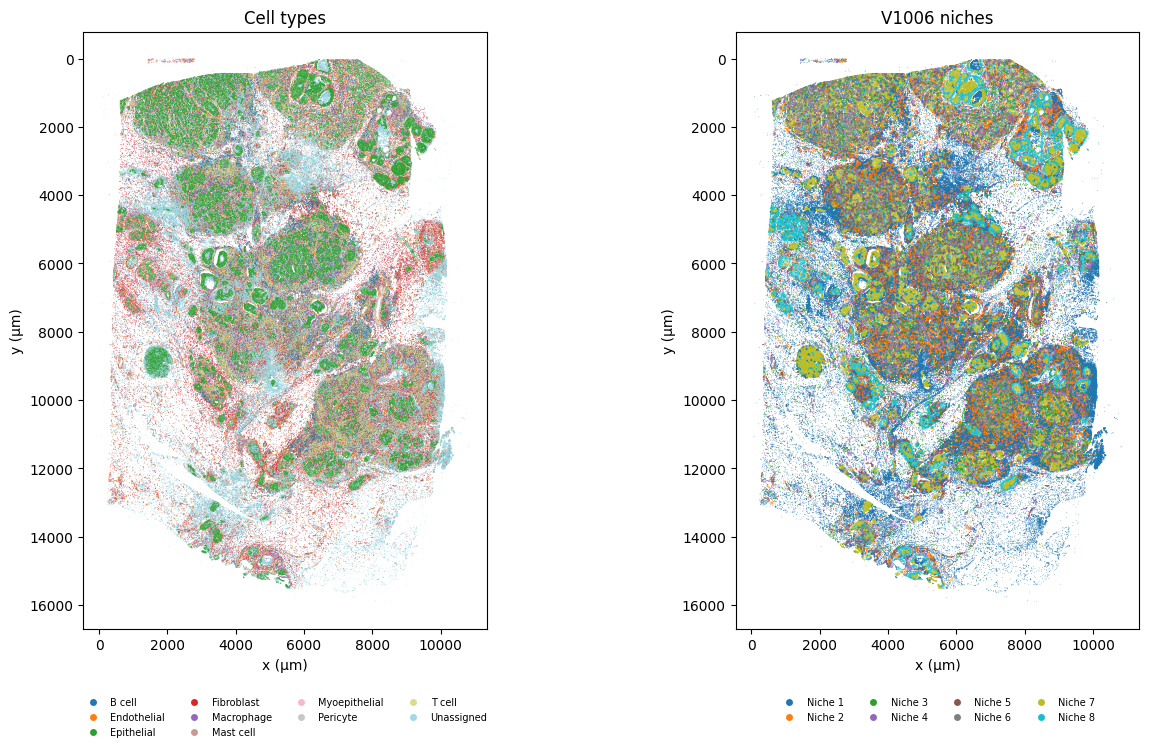

In [5]:
spatial_overview(artifacts); plt.show()

## 5. Niche size and proportion

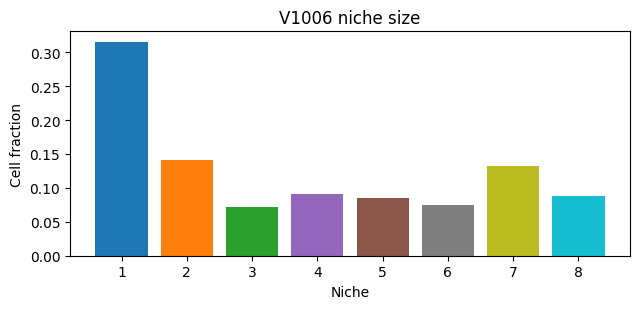

,niche,n_cells,fraction,mean_soft_usage
0,1,220307,0.315125,0.301300
1,2,98374,0.140713,0.144320
2,3,49890,0.071362,0.075687
3,4,64030,0.091588,0.093928
4,5,59171,0.084638,0.084190
5,6,52657,0.075320,0.077063
6,7,92757,0.132679,0.132890
7,8,61924,0.088575,0.089682


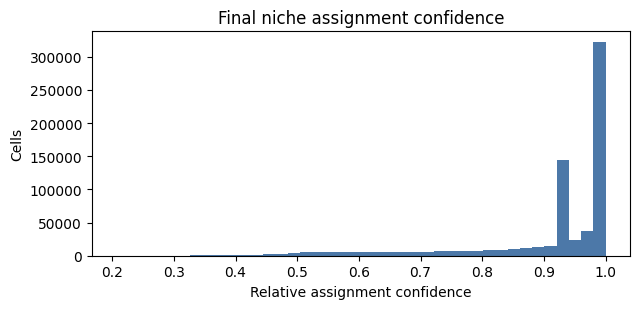

,confidence
count,699110.000000
mean,0.913787
std,0.135180
min,0.206808
10%,0.696897
25%,0.924391
50%,0.967226
75%,0.999232
90%,0.999983
max,1.000000


In [6]:
niche_size_plot(artifacts); plt.show()
display(artifacts['counts'])
confidence = artifacts['assignments']['assignment_confidence_relative']
fig, ax = plt.subplots(figsize=(6.5, 3.2)); ax.hist(confidence, bins=40, color='#4c78a8')
ax.set(xlabel='Relative assignment confidence', ylabel='Cells', title='Final niche assignment confidence')
plt.tight_layout(); plt.show()
pd.Series(confidence).describe(percentiles=[.1,.25,.5,.75,.9]).to_frame('confidence')

## 6. Cell-type / niche summary

Cell type is used here only after training.

/home/xueshuailin/miniconda3/envs/cccphe/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


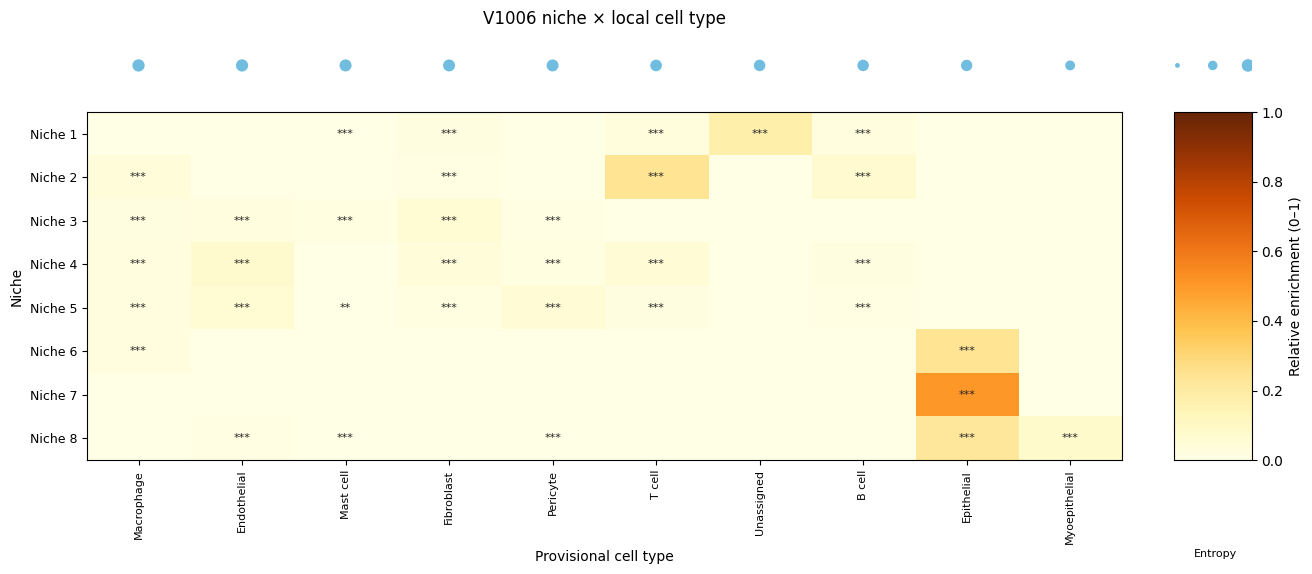

Stars: one-sided Mann–Whitney U, * p≤0.05, ** p≤0.001, *** p≤0.0001; dot size: across-niche entropy.


In [7]:
_, enrichment_table = niche_celltype_enrichment(artifacts); plt.show()
print('Stars: one-sided Mann–Whitney U, * p≤0.05, ** p≤0.001, *** p≤0.0001; dot size: across-niche entropy.')

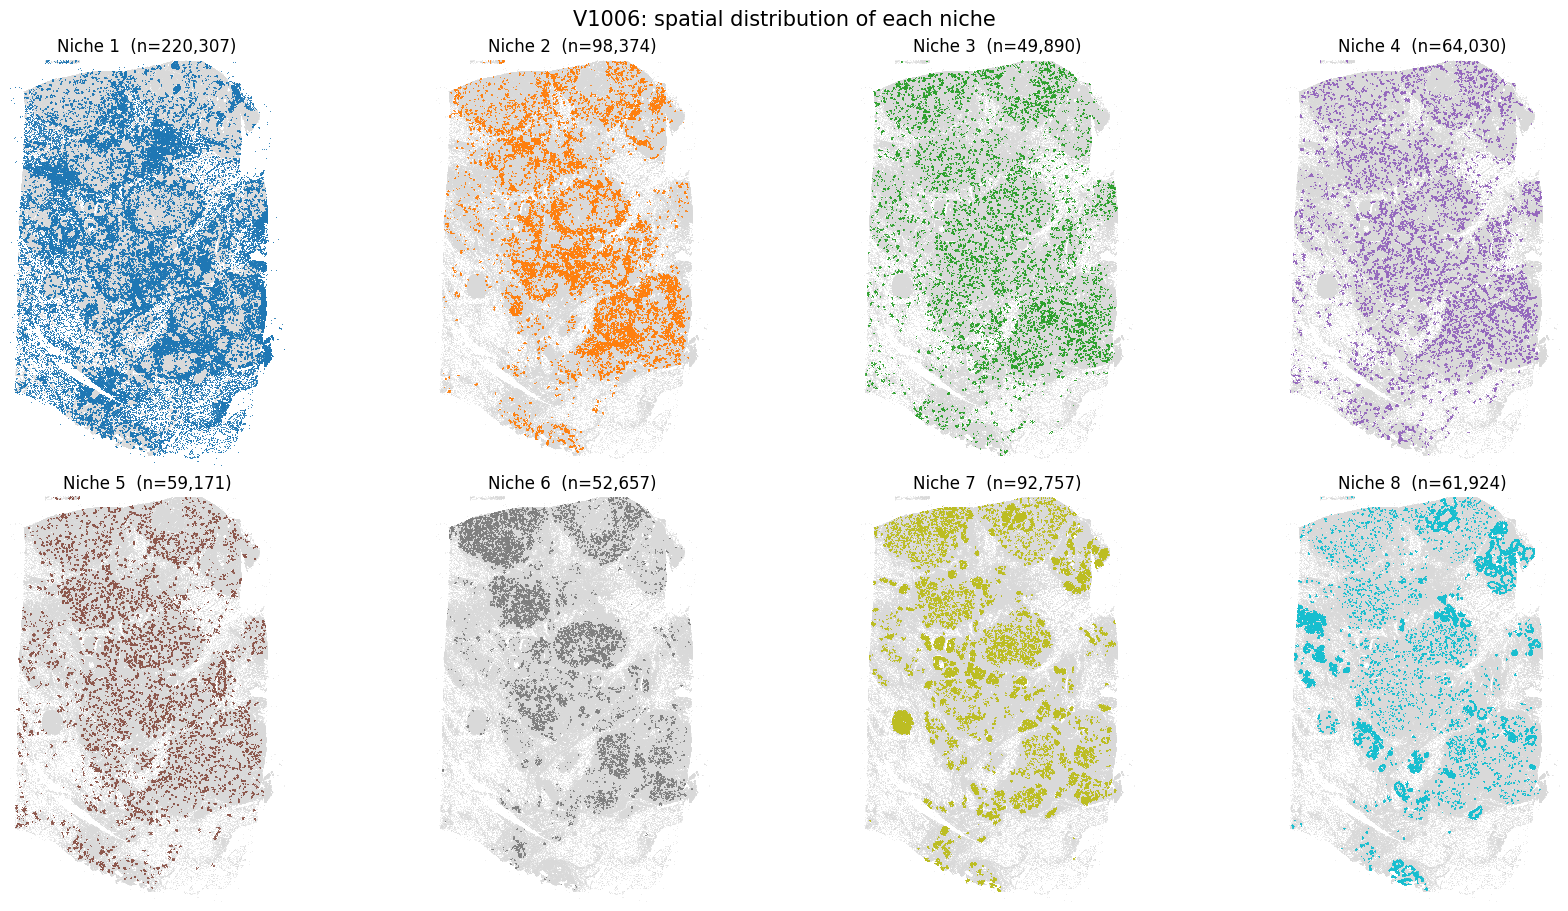

In [8]:
spatial_each_niche(artifacts); plt.show()

## 7. Representative CCC

In [9]:
for niche in range(1, 9):
    print(f'\nNiche {niche}')
    display(artifacts['top_ccc'].query('niche == @niche')[['rank','ccc','weight']].head(15).reset_index(drop=True))
print('Top sender → receiver')
display(pd.read_csv(output/'top_sender_receiver.csv').groupby('niche', group_keys=False).head(5))
print('Top ligand–receptor')
display(pd.read_csv(output/'top_lr.csv').groupby('niche', group_keys=False).head(5))


Niche 1


,rank,ccc,weight
0,1,Epithelial → Macrophage | TIMP3–CD44,0.069933
1,2,Epithelial → Macrophage | PKM–CD44,0.060626
2,3,Fibroblast → Macrophage | CCL2–CCR1,0.060182
3,4,Macrophage → Epithelial | CD44–EPCAM,0.057171
4,5,Fibroblast → Macrophage | TIMP3–CD44,0.055050
5,6,Macrophage → Epithelial | CD44–CLDN7,0.048501
6,7,Epithelial → Macrophage | VEGFA–CD44,0.045079
7,8,Epithelial → Macrophage | TIMP2–CD44,0.044766
8,9,Fibroblast → Macrophage | COL4A1–CD44,0.042659
9,10,Fibroblast → Macrophage | VEGFA–CD44,0.030106



Niche 2


,rank,ccc,weight
0,1,Fibroblast → Macrophage | THY1–ITGAX,0.123918
1,2,Fibroblast → Macrophage | THY1–ITGB2,0.120302
2,3,Macrophage → Fibroblast | ITGB2–THY1,0.120302
3,4,Macrophage → T cell | PKM–CD44,0.103709
4,5,Fibroblast → T cell | TIMP3–CD44,0.085236
5,6,Fibroblast → T cell | TIMP2–CD44,0.071858
6,7,Fibroblast → Macrophage | CCN1–ITGB2,0.058761
7,8,Fibroblast → Macrophage | CCN2–ITGB2,0.057441
8,9,Fibroblast → T cell | COL4A1–CD44,0.041109
9,10,Epithelial → T cell | TIMP3–CD44,0.026424



Niche 3


...

,rank,ccc,weight
0,1,Myoepithelial → Epithelial | THBS1–SDC4,0.019996
1,2,Myoepithelial → Epithelial | THBS1–ITGA3,0.018097
2,3,Myoepithelial → Myoepithelial | THBS1–ITGA3,0.017103
3,4,Myoepithelial → Epithelial | THBS1–CD47,0.016960
4,5,Myoepithelial → Epithelial | TIMP3–DDR1,0.016644
5,6,Epithelial → Myoepithelial | THBS1–ITGA3,0.014480
6,7,Epithelial → T cell | TIMP3–CD44,0.014186
7,8,Macrophage → Epithelial | GNAI2–IGF1R,0.013831
8,9,Epithelial → T cell | PKM–CD44,0.013084
9,10,Myoepithelial → Epithelial | TNC–SDC4,0.012920


Top sender → receiver


,niche,rank,sender,receiver,weight,sender_receiver
0,1,1,Epithelial,Epithelial,0.298677,Epithelial → Epithelial
1,1,2,Epithelial,Macrophage,0.234132,Epithelial → Macrophage
2,1,3,Fibroblast,Macrophage,0.227268,Fibroblast → Macrophage
3,1,4,Macrophage,Epithelial,0.117123,Macrophage → Epithelial
4,1,5,Endothelial,Macrophage,0.036493,Endothelial → Macrophage
15,2,1,Fibroblast,Macrophage,0.367311,Fibroblast → Macrophage
16,2,2,Fibroblast,T cell,0.211797,Fibroblast → T cell
17,2,3,Macrophage,Fibroblast,0.120302,Macrophage → Fibroblast
18,2,4,Macrophage,T cell,0.103709,Macrophage → T cell
19,2,5,Epithelial,T cell,0.072598,Epithelial → T cell


Top ligand–receptor


,niche,rank,ligand,receptor,weight,lr
0,1,1,TIMP3,CD44,0.157289,TIMP3–CD44
1,1,2,PKM,CD44,0.088630,PKM–CD44
2,1,3,VEGFA,CD44,0.086981,VEGFA–CD44
3,1,4,TIMP2,CD44,0.085119,TIMP2–CD44
4,1,5,CCL2,CCR1,0.078478,CCL2–CCR1
15,2,1,PKM,CD44,0.132139,PKM–CD44
16,2,2,THY1,ITGAX,0.124003,THY1–ITGAX
17,2,3,TIMP3,CD44,0.122949,TIMP3–CD44
18,2,4,ITGB2,THY1,0.120612,ITGB2–THY1
19,2,5,THY1,ITGB2,0.120612,THY1–ITGB2


## 8. Model-learned H8 CCC-program heatmap

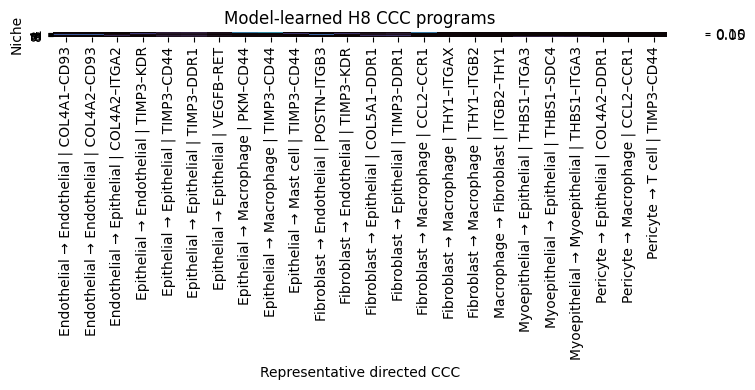

In [10]:
prepared = load_prepared_input(artifacts['config'])
representative_h_heatmap(artifacts['H8'], prepared.features); plt.show()

## 9. Model-learned 32 → 8 program consolidation

In [11]:
compact = (artifacts['mapping'].groupby('final_niche_id')
           .agg(latent_programs=('program_id', lambda x: ', '.join(map(str, x))),
                total_exposure=('mean_exposure','sum'))
           .reset_index())
display(compact)
h32_similarity = pd.read_csv(output/'H32_cosine_similarity.csv', index_col=0)
print(f'Maximum cross-niche H32 cosine: {summary["max_H32_cross_niche_cosine"]:.3f}')

,final_niche_id,latent_programs,total_exposure
0,1,"1, 2, 3, 4",1.184296
1,2,"5, 6, 7, 8",0.798362
2,3,"9, 10, 11, 12",1.808334
3,4,"13, 14, 15, 16",1.272507
4,5,"17, 18, 19, 20",1.860559
5,6,"21, 22, 23, 24",3.673066
6,7,"25, 26, 27, 28",3.637876
7,8,"29, 30, 31, 32",5.077616


Maximum cross-niche H32 cosine: 0.548


## 10. Final summary

In [12]:
top = artifacts['top_ccc'].query('rank == 1').set_index('niche')['ccc'].to_dict()
print(f"All 8 niches used: {not summary['niche_collapse']}")
print(f"Severe niche imbalance: {summary['severe_imbalance']}")
print(f"Largest niche fraction: {max(summary['niche_cell_fractions']):.3%}")
print(f"Mean assignment confidence: {summary['mean_assignment_confidence']:.3f}")
print(f"Effective learned programs: {summary['effective_programs']:.2f} / 32")
print(f"Maximum cross-niche H32 cosine: {summary['max_H32_cross_niche_cosine']:.3f}")
display(pd.Series(top, name='Top representative CCC').rename_axis('Niche').to_frame())

All 8 niches used: True
Severe niche imbalance: False
Largest niche fraction: 31.512%
Mean assignment confidence: 0.914
Effective learned programs: 19.92 / 32
Maximum cross-niche H32 cosine: 0.548


,Top representative CCC
Niche,
1,Epithelial → Macrophage | TIMP3–CD44
2,Fibroblast → Macrophage | THY1–ITGAX
3,Epithelial → Endothelial | TIMP3–KDR
4,Fibroblast → Endothelial | POSTN–ITGB3
5,Pericyte → Macrophage | CCL2–CCR1
6,Fibroblast → Epithelial | TIMP3–DDR1
7,Epithelial → Epithelial | TIMP3–DDR1
8,Myoepithelial → Epithelial | THBS1–SDC4
